步骤1：环境准备

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体显示
# plt.rcParams['font.sans-serif'] = ['SimHei']  # windows
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # macos
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

步骤2：参数设置

In [2]:
# 股票代码和参数设置
symbol = 'AAPL'        # 股票代码
period = '5y'          # 时间周期
short_period = 5       # 短期均线
long_period = 20       # 长期均线

步骤3：获取股票数据

In [3]:
# 获取股票数据
ticker = yf.Ticker(symbol)
df = ticker.history(period=period)
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2020-09-30 00:00:00-04:00,110.685542,114.060874,110.520182,112.650429,142675200,0.0,0.0
2020-10-01 00:00:00-04:00,114.430530,114.508350,112.669913,113.603722,116120400,0.0,0.0
2020-10-02 00:00:00-04:00,109.810103,112.222447,109.158384,109.936554,144712000,0.0,0.0
2020-10-05 00:00:00-04:00,110.802289,113.467534,110.452110,113.321625,106243800,0.0,0.0
2020-10-06 00:00:00-04:00,112.543458,112.952006,109.187585,110.072762,161498200,0.0,0.0
...,...,...,...,...,...,...,...
2025-09-23 00:00:00-04:00,255.880005,257.339996,253.580002,254.429993,60275200,0.0,0.0
2025-09-24 00:00:00-04:00,255.220001,255.740005,251.039993,252.309998,42303700,0.0,0.0
2025-09-25 00:00:00-04:00,253.210007,257.170013,251.710007,256.869995,55202100,0.0,0.0


In [5]:
# 存储股票数据（可以直接用）
df.index = df.index.tz_localize(None)  # 移除时区

file_name = "AAPL.csv"
df.to_csv(file_name)
df = pd.read_csv(file_name, index_col=0, parse_dates=True)
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2020-09-30,110.685542,114.060874,110.520182,112.650429,142675200,0.0,0.0
2020-10-01,114.430530,114.508350,112.669913,113.603722,116120400,0.0,0.0
2020-10-02,109.810103,112.222447,109.158384,109.936554,144712000,0.0,0.0
2020-10-05,110.802289,113.467534,110.452110,113.321625,106243800,0.0,0.0
2020-10-06,112.543458,112.952006,109.187585,110.072762,161498200,0.0,0.0


步骤4：计算移动平均线指标

In [9]:
# df['Close'].head(10)
# help(df['Close'].rolling)

In [10]:
# SMA (简单移动平均线)
df['SMA_short'] = df['Close'].rolling(short_period).mean()
df['SMA_long'] = df['Close'].rolling(long_period).mean()

# EMA (指数移动平均线)
# df['EMA_short'] = df['Close'].ewm(span=short_period).mean()
# df['EMA_long'] = df['Close'].ewm(span=long_period).mean()

df[['Close','SMA_short','SMA_long']].head(20)

,Close,SMA_short,SMA_long
Date,,,
2020-09-30,112.650429,NaN,NaN
2020-10-01,113.603722,NaN,NaN
2020-10-02,109.936554,NaN,NaN
2020-10-05,113.321625,NaN,NaN
2020-10-06,110.072762,111.917018,NaN
2020-10-07,111.940369,111.775006,NaN
2020-10-08,111.833351,111.420932,NaN
2020-10-09,113.778801,112.189381,NaN
2020-10-12,121.006088,113.726274,NaN


步骤5：分析趋势信号

In [13]:
# df[['Close','SMA_short','SMA_long']].head(22)
# help(df['SMA_short'].shift)

In [19]:
# 金叉死叉信号：同时满足2个条件，如：（昨天的短均线<=长均线）&（今天的短均线>=长均线）=> shift
df['SMA_golden_cross'] = (df['SMA_short'].shift(1)<=df['SMA_long'].shift(1)) & (df['SMA_short']>=df['SMA_long'])
df['SMA_death_cross'] = (df['SMA_short'].shift(1)>=df['SMA_long'].shift(1)) & (df['SMA_short']<=df['SMA_long'])

# 趋势判断：上升 or 下降
df['SMA_trend'] = np.NaN
df.loc[df['SMA_short'] > df['SMA_long'], 'SMA_trend'] = 'Up'
df.loc[df['SMA_short'] < df['SMA_long'], 'SMA_trend'] = 'Down'

df[['Close','SMA_short','SMA_long','SMA_golden_cross','SMA_death_cross','SMA_trend']].tail(20)

,Close,SMA_short,SMA_long,SMA_golden_cross,SMA_death_cross,SMA_trend
Date,,,,,,
2025-09-02,229.720001,230.844000,227.029938,False,False,Up
2025-09-03,238.470001,232.676001,228.818940,False,False,Up
2025-09-04,239.779999,234.534000,230.157527,False,False,Up
2025-09-05,239.690002,235.960001,231.152999,False,False,Up
2025-09-08,237.880005,237.108002,231.592499,False,False,Up
2025-09-09,234.350006,238.034003,231.950999,False,False,Up
2025-09-10,226.789993,235.698001,231.807999,False,False,Up
2025-09-11,230.029999,233.748001,231.642999,False,False,Up
2025-09-12,234.070007,232.624002,231.707500,False,False,Up


步骤6：统计历史趋势

In [20]:
# SMA统计
sma_up_days = len(df[df['SMA_trend']=='Up'])
sma_down_days = len(df[df['SMA_trend']=='Down'])
sma_golden_cross_count = df['SMA_golden_cross'].sum() # 计算True的个数
sma_death_cross_count = df['SMA_death_cross'].sum()

sma_up_days,sma_down_days,sma_golden_cross_count,sma_death_cross_count

(721, 515, 34, 33)

步骤7：显示历史统计

In [21]:
# 显示历史统计
print(f"\n📈 历史趋势统计")
print("=" * 50)

print(f"SMA{short_period}/{long_period} 统计:")
print(f"  上升趋势: {sma_up_days} 天 ({sma_up_days/len(df)*100:.1f}%)")
print(f"  下降趋势: {sma_down_days} 天 ({sma_down_days/len(df)*100:.1f}%)")
print(f"  金叉次数: {sma_golden_cross_count} 次")
print(f"  死叉次数: {sma_death_cross_count} 次")


📈 历史趋势统计
SMA5/20 统计:
  上升趋势: 721 天 (57.5%)
  下降趋势: 515 天 (41.0%)
  金叉次数: 34 次
  死叉次数: 33 次


步骤8：分析当前趋势

In [22]:
# 分析当前趋势（简化版：单一强度标准）
print(f"\n🎯 {symbol} 当前趋势分析")
print("=" * 50)

latest = df.iloc[-1]

# 距离与强度（以历史平均为基准）
sma_distance = abs(latest['SMA_short'] - latest['SMA_long'])
sma_distance_pct = (sma_distance / latest['SMA_long']) * 100 if latest['SMA_long'] != 0 else 0.0
sma_avg_distance = abs(df['SMA_short'] - df['SMA_long']).mean()
sma_strength_ratio = sma_distance / sma_avg_distance if sma_avg_distance != 0 else 0.0

# 单一判断标准：强度是否大于历史平均（>1.0）
is_strong = sma_strength_ratio > 1.0
sma_trend = latest['SMA_trend']  # 取值：'Up' / 'Down' / 其它

# 趋势信号（仅强/弱两档）
if sma_trend == 'Up':
    sma_signal = "📈 上升-强" if is_strong else "📈 上升-弱"
elif sma_trend == 'Down':
    sma_signal = "📉 下降-强" if is_strong else "📉 下降-弱"
else:
    sma_signal = "➡️ 横盘"

print(f"SMA趋势: {sma_signal}")
print(f"  SMA{short_period}: {latest['SMA_short']:.2f}")
print(f"  SMA{long_period}: {latest['SMA_long']:.2f}")
print(f"  距离: {sma_distance:.2f} ({sma_distance_pct:.2f}%)")
print(f"  强度倍数: {sma_strength_ratio:.2f}x")

# 综合趋势（同一标准）
if sma_trend == 'Up':
    overall = "🟢 上升-强" if is_strong else "🟡 上升-弱"
elif sma_trend == 'Down':
    overall = "🔴 下降-强" if is_strong else "🟠 下降-弱"
else:
    overall = "⚪ 横盘"

print(f"\n综合趋势: {overall}")
print(f"  强度倍数: {sma_strength_ratio:.2f}x")


🎯 AAPL 当前趋势分析
SMA趋势: 📈 上升-强
  SMA5: 254.70
  SMA20: 241.88
  距离: 12.82 (5.30%)
  强度倍数: 2.85x

综合趋势: 🟢 上升-强
  强度倍数: 2.85x


步骤9：绘制图表


📊 绘制分析图表...
✅ 分析完成！


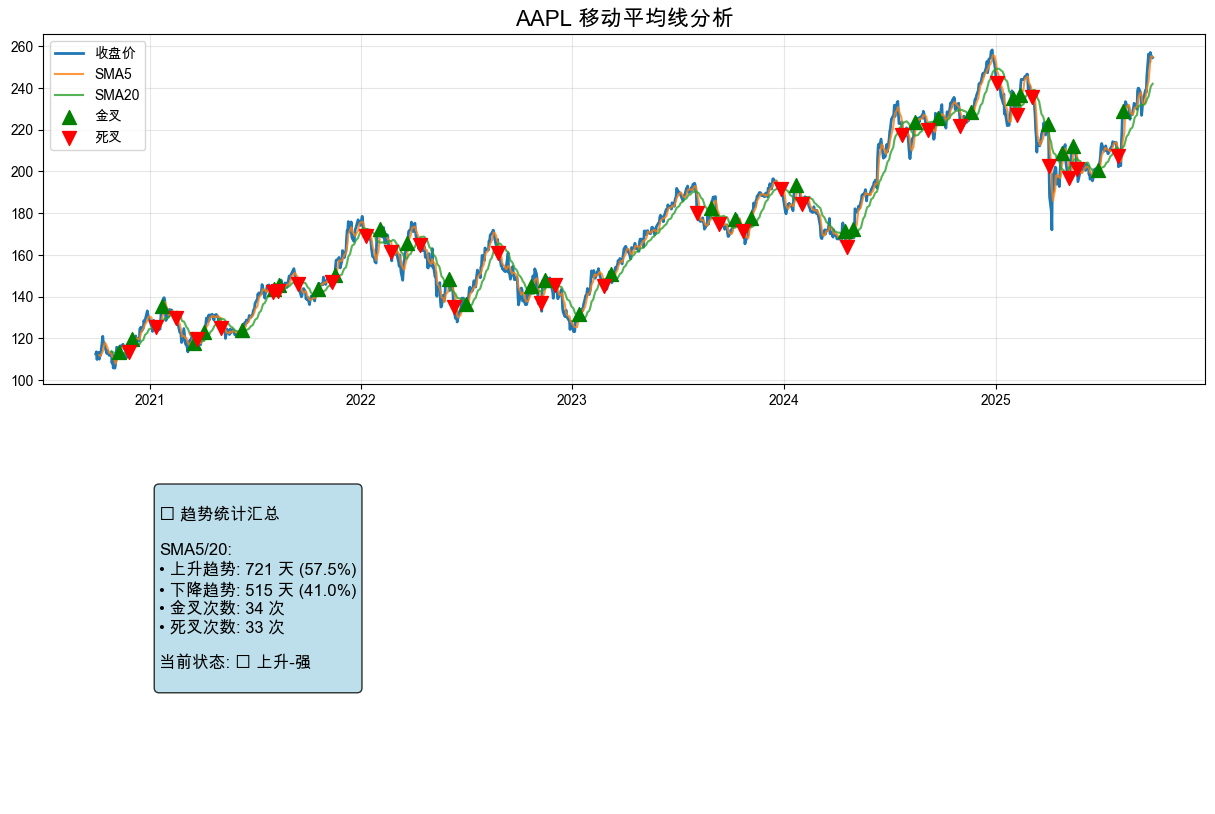

In [23]:
# 绘制图表
print("\n📊 绘制分析图表...")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# 价格和移动平均线
ax1.plot(df.index, df['Close'], label='收盘价', linewidth=2)
ax1.plot(df.index, df['SMA_short'], label=f'SMA{short_period}', alpha=0.8)
ax1.plot(df.index, df['SMA_long'], label=f'SMA{long_period}', alpha=0.8)

# 标记金叉死叉
golden_cross = df[df['SMA_golden_cross']]
death_cross = df[df['SMA_death_cross']]

ax1.scatter(golden_cross.index, golden_cross['Close'], 
            color='green', marker='^', s=100, label='金叉', zorder=5)
ax1.scatter(death_cross.index, death_cross['Close'], 
            color='red', marker='v', s=100, label='死叉', zorder=5)

ax1.set_title(f'{symbol} 移动平均线分析', fontsize=16)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 趋势统计
ax2.axis('off')

stats_text = f"""
📊 趋势统计汇总

SMA{short_period}/{long_period}:
• 上升趋势: {sma_up_days} 天 ({sma_up_days/len(df)*100:.1f}%)
• 下降趋势: {sma_down_days} 天 ({sma_down_days/len(df)*100:.1f}%)
• 金叉次数: {sma_golden_cross_count} 次
• 死叉次数: {sma_death_cross_count} 次

当前状态: {overall}
"""

ax2.text(0.1, 0.9, stats_text, transform=ax2.transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))


print("✅ 分析完成！")